**Python Notebook 3 – Ensemble Classifier and Regression Decision Trees**

Module: 5DATA002W.2 – Machine Learning & Data Mining

Author: Shane Rowell

Peer Reviewer: Dasika Ruvishan

Review Date: 25/03/2026

Dataset: loan_approval_data.csv

**Step 1 – Import Libraries**

In [1]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import seaborn for statistical visualisation
import seaborn as sns

# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# Import StandardScaler to normalise feature values
from sklearn.preprocessing import StandardScaler

# Import LabelEncoder to convert categorical text into numerical form
from sklearn.preprocessing import LabelEncoder

# Import Logistic Regression classifier
from sklearn.linear_model import LogisticRegression

# Import Gaussian Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

# Import VotingClassifier to combine base learners into an ensemble
from sklearn.ensemble import VotingClassifier

# Import Decision Tree regressor and visualisation tools
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

# Import classification evaluation metrics
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve,
                             roc_auc_score, f1_score)

# Import regression evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

***PART A – ENSEMBLE CLASSIFIER***

**Step 2 – Load and Preprocess Classification Data**

In [2]:
# Load the raw dataset
df = pd.read_csv('loan_approval_data.csv')

# Drop max_allowed_loan to prevent data leakage in the classification section
df_class = df.drop(columns=['max_allowed_loan', 'id'], errors='ignore')

# Impute missing numerical values with the column mean
df_class['age'] = df_class['age'].fillna(df_class['age'].mean())
df_class['loan_interest_rate'] = df_class['loan_interest_rate'].fillna(df_class['loan_interest_rate'].mean())
df_class['loan_income_ratio'] = df_class['loan_income_ratio'].fillna(df_class['loan_income_ratio'].mean())
df_class['credit_history_length'] = df_class['credit_history_length'].fillna(df_class['credit_history_length'].mean())
df_class['emplyment_length'] = df_class['emplyment_length'].fillna(df_class['emplyment_length'].mean())
df_class['income'] = df_class['income'].fillna(df_class['income'].mean())
df_class['loan_amount'] = df_class['loan_amount'].fillna(df_class['loan_amount'].mean())

# Impute missing categorical values with the column mode
df_class['home_ownership'] = df_class['home_ownership'].fillna(df_class['home_ownership'].mode()[0])
df_class['loan_intent'] = df_class['loan_intent'].fillna(df_class['loan_intent'].mode()[0])
df_class['payment_default_on_file'] = df_class['payment_default_on_file'].fillna(df_class['payment_default_on_file'].mode()[0])

# Encode categorical columns into integers using LabelEncoder
le = LabelEncoder()
df_class['home_ownership'] = le.fit_transform(df_class['home_ownership'])
df_class['loan_intent'] = le.fit_transform(df_class['loan_intent'])
df_class['payment_default_on_file'] = le.fit_transform(df_class['payment_default_on_file'])

# Confirm preprocessing completed successfully
print("Classification dataset shape:", df_class.shape)
print("Remaining missing values:", df_class.isnull().sum().sum())

Classification dataset shape: (58645, 11)
Remaining missing values: 0


**Step 3 – Define Features, Target and Split**

In [3]:
# Define input features by dropping the target column
X = df_class.drop(columns=['loan_approval_status'])

# Define the target variable
y = df_class['loan_approval_status']

# Split into 80% training and 20% testing with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply StandardScaler fitted on training data only to prevent leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Testing set size:", X_test_scaled.shape)

Training set size: (46916, 10)
Testing set size: (11729, 10)


**Step 4 – Declare and Train Base Learners**

In [4]:
# Declare the Logistic Regression base learner
lr_base = LogisticRegression(random_state=42, max_iter=1000)

# Declare the Naive Bayes base learner
nb_base = GaussianNB()

# Train Logistic Regression on the scaled training data
lr_base.fit(X_train_scaled, y_train)

# Train Naive Bayes on the scaled training data
nb_base.fit(X_train_scaled, y_train)

print("Base learners trained successfully.")

Base learners trained successfully.


Step 4a – Evaluate Logistic Regression Base Learner

Logistic Regression Accuracy: 0.8902


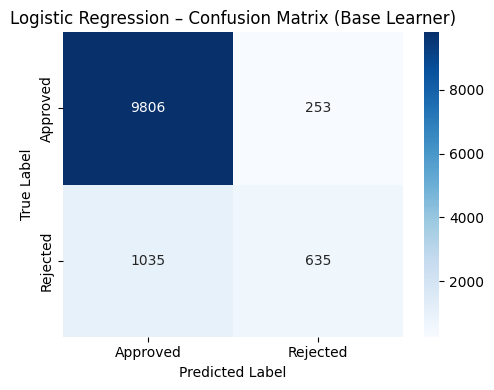

              precision    recall  f1-score   support

    Approved       0.90      0.97      0.94     10059
    Rejected       0.72      0.38      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.81      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729

Logistic Regression AUC: 0.8714


In [5]:
# Generate predictions from Logistic Regression
y_pred_lr = lr_base.predict(X_test_scaled)

# Print accuracy
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))

# Plot confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Approved', 'Rejected'],
            yticklabels=['Approved', 'Rejected'])
plt.title('Logistic Regression – Confusion Matrix (Base Learner)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Print classification report
print(classification_report(y_test, y_pred_lr, target_names=['Approved', 'Rejected']))

# Compute and print AUC score
lr_auc = roc_auc_score(y_test, lr_base.predict_proba(X_test_scaled)[:, 1])
print("Logistic Regression AUC:", round(lr_auc, 4))

Step 4b – ROC Curve for Logistic Regression Base Learner

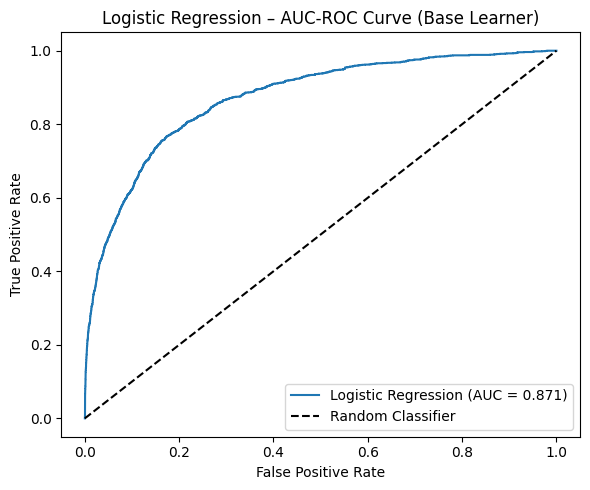

In [6]:
# Compute ROC curve values for Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_base.predict_proba(X_test_scaled)[:, 1])

# Plot the ROC curve
plt.figure(figsize=(6, 5))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('Logistic Regression – AUC-ROC Curve (Base Learner)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Step 4c – Evaluate Naive Bayes Base Learner

Naive Bayes Accuracy: 0.8493


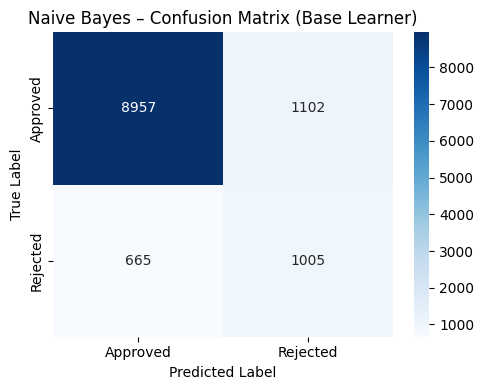

              precision    recall  f1-score   support

    Approved       0.93      0.89      0.91     10059
    Rejected       0.48      0.60      0.53      1670

    accuracy                           0.85     11729
   macro avg       0.70      0.75      0.72     11729
weighted avg       0.87      0.85      0.86     11729

Naive Bayes AUC: 0.8548


In [7]:
# Generate predictions from Naive Bayes
y_pred_nb = nb_base.predict(X_test_scaled)

# Print accuracy
print("Naive Bayes Accuracy:", round(accuracy_score(y_test, y_pred_nb), 4))

# Plot confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Approved', 'Rejected'],
            yticklabels=['Approved', 'Rejected'])
plt.title('Naive Bayes – Confusion Matrix (Base Learner)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Print classification report
print(classification_report(y_test, y_pred_nb, target_names=['Approved', 'Rejected']))

# Compute and print AUC score
nb_auc = roc_auc_score(y_test, nb_base.predict_proba(X_test_scaled)[:, 1])
print("Naive Bayes AUC:", round(nb_auc, 4))

Step 4d – ROC Curve for Naive Bayes Base Learner

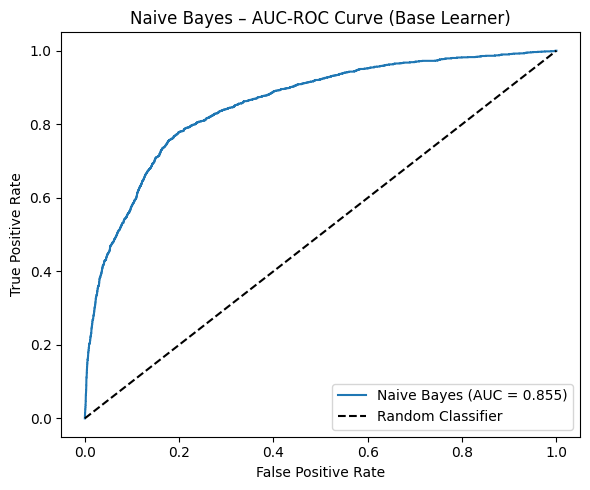

In [8]:
# Compute ROC curve values for Naive Bayes
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_base.predict_proba(X_test_scaled)[:, 1])

# Plot the ROC curve
plt.figure(figsize=(6, 5))
plt.plot(nb_fpr, nb_tpr, label=f'Naive Bayes (AUC = {nb_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('Naive Bayes – AUC-ROC Curve (Base Learner)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Step 5 – Build the Voting Ensemble Classifier**

In [9]:
# Declare the voting ensemble using Logistic Regression and Naive Bayes
# voting='soft' means predictions are based on averaged class probabilities
ensemble = VotingClassifier(
    estimators=[
        ('Logistic Regression', LogisticRegression(random_state=42, max_iter=1000)),
        ('Naive Bayes', GaussianNB())
    ],
    voting='soft'
)

# Fit the ensemble on the scaled training data
ensemble.fit(X_train_scaled, y_train)

print("Ensemble classifier trained successfully.")

Ensemble classifier trained successfully.


Step 5a – Evaluate the Voting Ensemble Classifier

Ensemble Classifier Accuracy: 0.8795


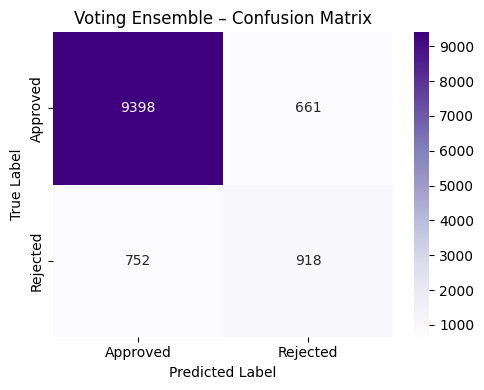

              precision    recall  f1-score   support

    Approved       0.93      0.93      0.93     10059
    Rejected       0.58      0.55      0.57      1670

    accuracy                           0.88     11729
   macro avg       0.75      0.74      0.75     11729
weighted avg       0.88      0.88      0.88     11729



In [10]:
# Generate predictions from the ensemble
y_pred_ensemble = ensemble.predict(X_test_scaled)

# Print accuracy
print("Ensemble Classifier Accuracy:", round(accuracy_score(y_test, y_pred_ensemble), 4))

# Plot confusion matrix in purple to visually distinguish from base learners
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Approved', 'Rejected'],
            yticklabels=['Approved', 'Rejected'])
plt.title('Voting Ensemble – Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Print classification report
print(classification_report(y_test, y_pred_ensemble, target_names=['Approved', 'Rejected']))

Step 5b – Ensemble vs Base Learners Comparison

In [11]:
# Build a summary comparison table across both base learners and the ensemble
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Voting Ensemble'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_nb), 4),
        round(accuracy_score(y_test, y_pred_ensemble), 4)
    ],
    'F1 Score (Approved)': [
        round(f1_score(y_test, y_pred_lr), 4),
        round(f1_score(y_test, y_pred_nb), 4),
        round(f1_score(y_test, y_pred_ensemble), 4)
    ]
})

print("Ensemble vs Base Learners – Performance Comparison")
print(comparison.to_string(index=False))

Ensemble vs Base Learners – Performance Comparison
              Model  Accuracy  F1 Score (Approved)
Logistic Regression    0.8902               0.4965
        Naive Bayes    0.8493               0.5322
    Voting Ensemble    0.8795               0.5651


***PART B – REGRESSION DECISION TREES***

**Step 6 – Load and Preprocess Regression Dataset**

In [12]:
# Reload the original dataset fresh for the regression section
df_reg = pd.read_csv('loan_approval_data.csv')

# Filter to approved loans only — status = 0 means Approved in this dataset
df_reg = df_reg[df_reg['loan_approval_status'] == 0].copy()

# Remove rows where max_allowed_loan is negative as these are data entry errors
df_reg = df_reg[df_reg['max_allowed_loan'] > 0].copy()

print("Approved records after cleaning:", len(df_reg))
print("max_allowed_loan stats:")
print(df_reg['max_allowed_loan'].describe())

Approved records after cleaning: 50292
max_allowed_loan stats:
count    5.029200e+04
mean     8.139253e+04
std      5.812145e+04
min      2.320000e+02
25%      4.911050e+04
50%      6.943150e+04
75%      9.899100e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64


Step 6a – Preprocess Regression Dataset

In [13]:
# Drop id and loan_approval_status as they are not useful features for regression
df_reg = df_reg.drop(columns=['id', 'loan_approval_status'], errors='ignore')

# Impute missing numerical values with the column mean
df_reg['age'] = df_reg['age'].fillna(df_reg['age'].mean())
df_reg['loan_interest_rate'] = df_reg['loan_interest_rate'].fillna(df_reg['loan_interest_rate'].mean())
df_reg['loan_income_ratio'] = df_reg['loan_income_ratio'].fillna(df_reg['loan_income_ratio'].mean())
df_reg['credit_history_length'] = df_reg['credit_history_length'].fillna(df_reg['credit_history_length'].mean())
df_reg['emplyment_length'] = df_reg['emplyment_length'].fillna(df_reg['emplyment_length'].mean())
df_reg['income'] = df_reg['income'].fillna(df_reg['income'].mean())
df_reg['loan_amount'] = df_reg['loan_amount'].fillna(df_reg['loan_amount'].mean())
df_reg['home_ownership'] = df_reg['home_ownership'].fillna(df_reg['home_ownership'].mode()[0])
df_reg['loan_intent'] = df_reg['loan_intent'].fillna(df_reg['loan_intent'].mode()[0])
df_reg['payment_default_on_file'] = df_reg['payment_default_on_file'].fillna(df_reg['payment_default_on_file'].mode()[0])

# Encode categorical columns into integers using LabelEncoder
le = LabelEncoder()
df_reg['home_ownership'] = le.fit_transform(df_reg['home_ownership'])
df_reg['loan_intent'] = le.fit_transform(df_reg['loan_intent'])
df_reg['payment_default_on_file'] = le.fit_transform(df_reg['payment_default_on_file'])

# Confirm final dataset shape and missing values
print("Regression dataset shape:", df_reg.shape)
print("Remaining missing values:", df_reg.isnull().sum().sum())
print("Columns:", df_reg.columns.tolist())

Regression dataset shape: (50292, 11)
Remaining missing values: 0
Columns: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'max_allowed_loan']


**Step 7 – Define Features, Target and Split**

In [14]:
# Define input features by dropping the regression target
X_reg = df_reg.drop(columns=['max_allowed_loan'])

# Define the regression target variable
y_reg = df_reg['max_allowed_loan']

# Split into 80% training and 20% testing
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

print("Regression training set size:", X_reg_train.shape)
print("Regression testing set size:", X_reg_test.shape)
print("Target sample values:", y_reg_train.head(5).values)
print("Target unique values:", y_reg.nunique())

Regression training set size: (40233, 10)
Regression testing set size: (10059, 10)
Target sample values: [ 59624  27381  95656  43373 109470]
Target unique values: 22584


**Step 8 – Build DT-1: Fully Grown Decision Tree Regressor**

In [15]:
# Declare and train DT-1 with no depth restriction
dt1 = DecisionTreeRegressor(random_state=42)

# Fit on the regression training data
dt1.fit(X_reg_train, y_reg_train)

# Generate predictions on the test set
y_pred_dt1 = dt1.predict(X_reg_test)

print("DT-1 (Fully Grown) trained successfully.")
print("Tree depth:", dt1.get_depth())
print("Number of leaves:", dt1.get_n_leaves())

DT-1 (Fully Grown) trained successfully.
Tree depth: 25
Number of leaves: 22950


**Step 9 – Build DT-2: Pruned Decision Tree Regressor** (Depth = 4)

In [16]:
# Declare and train DT-2 limited to a maximum depth of 4 levels
dt2 = DecisionTreeRegressor(max_depth=4, random_state=42)

# Fit on the regression training data
dt2.fit(X_reg_train, y_reg_train)

# Generate predictions on the test set
y_pred_dt2 = dt2.predict(X_reg_test)

print("DT-2 (Pruned to 4 levels) trained successfully.")
print("Tree depth:", dt2.get_depth())
print("Number of leaves:", dt2.get_n_leaves())

DT-2 (Pruned to 4 levels) trained successfully.
Tree depth: 4
Number of leaves: 16


**Step 10 – Visualise DT-1: Fully Grown Decision Tree** (Depth = 4)

In [17]:
# Print DT-1 stats — the full tree is too large to render as a graphic
print("DT-1 – Fully Grown Decision Tree Regressor")
print("Full tree depth:", dt1.get_depth())
print("Total number of leaves:", dt1.get_n_leaves())
print()

# Print the top 3 levels of the tree as text for the Analysis Report
print("DT-1 – Top 3 Levels of Decision Rules:")
print(export_text(dt1, feature_names=X_reg.columns.tolist(), max_depth=3))

DT-1 – Fully Grown Decision Tree Regressor
Full tree depth: 25
Total number of leaves: 22950

DT-1 – Top 3 Levels of Decision Rules:
|--- income <= 87202.00
|   |--- income <= 57582.00
|   |   |--- income <= 40329.50
|   |   |   |--- age <= 27.78
|   |   |   |   |--- truncated branch of depth 20
|   |   |   |--- age >  27.78
|   |   |   |   |--- truncated branch of depth 20
|   |   |--- income >  40329.50
|   |   |   |--- age <= 27.78
|   |   |   |   |--- truncated branch of depth 19
|   |   |   |--- age >  27.78
|   |   |   |   |--- truncated branch of depth 20
|   |--- income >  57582.00
|   |   |--- age <= 28.50
|   |   |   |--- income <= 70936.00
|   |   |   |   |--- truncated branch of depth 18
|   |   |   |--- income >  70936.00
|   |   |   |   |--- truncated branch of depth 19
|   |   |--- age >  28.50
|   |   |   |--- income <= 69668.00
|   |   |   |   |--- truncated branch of depth 18
|   |   |   |--- income >  69668.00
|   |   |   |   |--- truncated branch of depth 19
|--- in

**Step 11 – Visualise DT-2: Pruned Decision Tree**

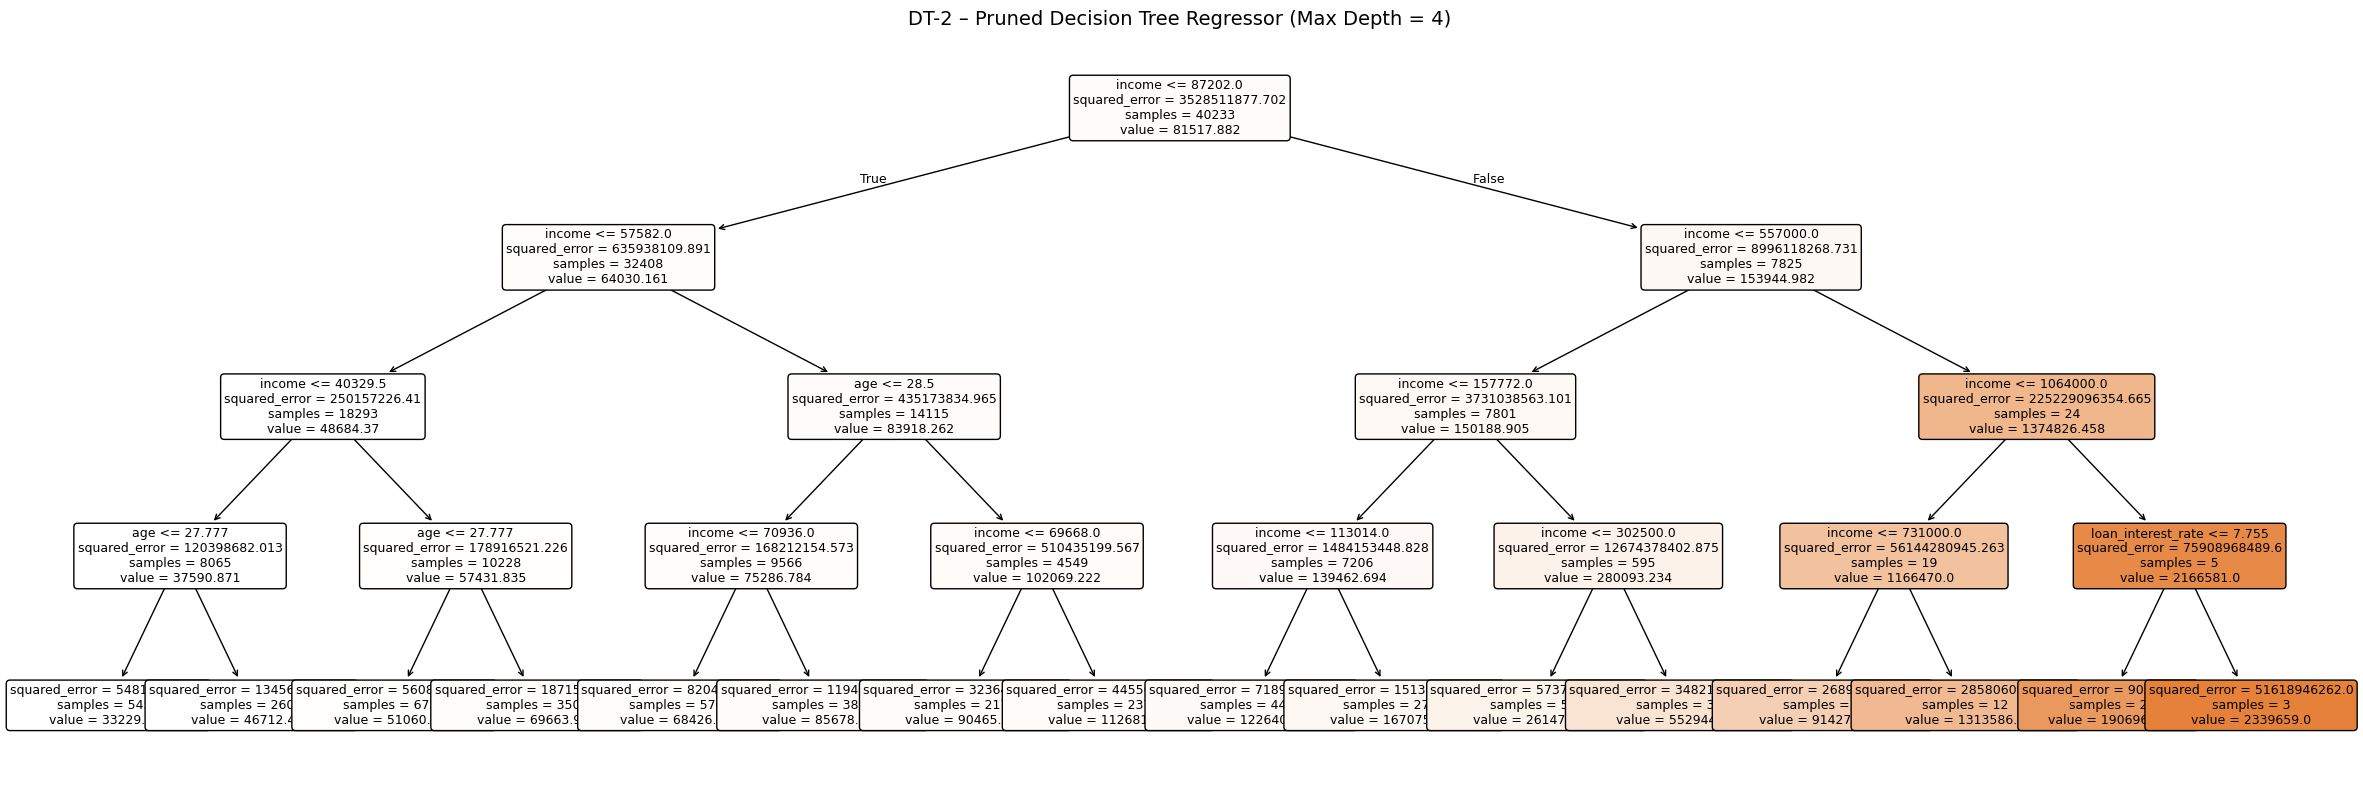

DT-2 visualisation saved as DT2_pruned.png


In [18]:
# Visualise DT-2 as a graphical plot — manageable size due to max_depth=4
plt.figure(figsize=(24, 8))

# Plot the pruned tree with feature names for readability
plot_tree(dt2,
          feature_names=X_reg.columns.tolist(),
          filled=True,
          rounded=True,
          fontsize=9)

# Add title
plt.title('DT-2 – Pruned Decision Tree Regressor (Max Depth = 4)', fontsize=14)
plt.tight_layout()

# Save as high resolution PNG for the Analysis Report
plt.savefig('DT2_pruned.png', dpi=150, bbox_inches='tight')
plt.show()

print("DT-2 visualisation saved as DT2_pruned.png")

**Step 12 – Evaluate Both Regression Models**

In [19]:
# Compute evaluation metrics for DT-1
mse_dt1 = mean_squared_error(y_reg_test, y_pred_dt1)
mae_dt1 = mean_absolute_error(y_reg_test, y_pred_dt1)
r2_dt1 = r2_score(y_reg_test, y_pred_dt1)

# Compute evaluation metrics for DT-2
mse_dt2 = mean_squared_error(y_reg_test, y_pred_dt2)
mae_dt2 = mean_absolute_error(y_reg_test, y_pred_dt2)
r2_dt2 = r2_score(y_reg_test, y_pred_dt2)

# Display results in a comparison table
results = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'R-Squared'],
    'DT-1 (Fully Grown)': [round(mse_dt1, 2), round(mae_dt1, 2), round(r2_dt1, 4)],
    'DT-2 (Pruned)':      [round(mse_dt2, 2), round(mae_dt2, 2), round(r2_dt2, 4)]
})

print("Regression Model Evaluation – DT-1 vs DT-2")
print(results.to_string(index=False))

Regression Model Evaluation – DT-1 vs DT-2
   Metric  DT-1 (Fully Grown)  DT-2 (Pruned)
      MSE        4.953165e+07   3.747229e+08
      MAE        1.213790e+03   1.180104e+04
R-Squared        9.822000e-01   8.650000e-01


**Step 13 – Check Encoding Mappings for Client 60256**

In [20]:
# Reload raw data to extract original category strings for encoding reference
df_raw_check = pd.read_csv('loan_approval_data.csv')

# Create a temporary LabelEncoder to print mappings
temp_le = LabelEncoder()

# Print home_ownership encoding mapping
home_categories = sorted(df_raw_check['home_ownership'].dropna().unique())
print("home_ownership encoding:")
print(dict(zip(home_categories, temp_le.fit_transform(home_categories))))

# Print loan_intent encoding mapping
intent_categories = sorted(df_raw_check['loan_intent'].dropna().unique())
print("\nloan_intent encoding:")
print(dict(zip(intent_categories, temp_le.fit_transform(intent_categories))))

# Print payment_default_on_file encoding mapping
default_categories = sorted(df_raw_check['payment_default_on_file'].dropna().unique())
print("\npayment_default_on_file encoding:")
print(dict(zip(default_categories, temp_le.fit_transform(default_categories))))

home_ownership encoding:
{'MORTGAGE': np.int64(0), 'OTHER': np.int64(1), 'OWN': np.int64(2), 'RENT': np.int64(3)}

loan_intent encoding:
{'DEBTCONSOLIDATION': np.int64(0), 'EDUCATION': np.int64(1), 'HOMEIMPROVEMENT': np.int64(2), 'MEDICAL': np.int64(3), 'PERSONAL': np.int64(4), 'VENTURE': np.int64(5)}

payment_default_on_file encoding:
{'N': np.int64(0), 'Y': np.int64(1)}


Step 13a – Predict Maximum Loan Amount for Client 60256

In [21]:
# Construct the feature row for Client 60256
# Integer values confirmed from encoding output in Step 13
client_60256 = pd.DataFrame([{
    'age': 56,
    'income': 57000,
    'home_ownership': 3,           # RENT = 3
    'emplyment_length': 15,
    'loan_intent': 3,              # MEDICAL = 3
    'loan_amount': 25700,
    'loan_interest_rate': 23.0,
    'loan_income_ratio': 0.10,
    'payment_default_on_file': 0,  # N (No) = 0
    'credit_history_length': 35
}])

# Ensure column order matches the training data exactly
client_60256 = client_60256[X_reg.columns]

# Predict using DT-1 as it is the best performing regression model
prediction = dt1.predict(client_60256)

print("Client 60256 – Predicted Maximum Loan Amount:")
print(f"GBP {round(prediction[0], 2):,.2f}")

Client 60256 – Predicted Maximum Loan Amount:
GBP 83,097.00


Step 13b – Decision Path for Client 60256

In [22]:
# Print the top 5 levels of DT-1 decision rules to show the path for Client 60256
# The full tree is 25 levels deep so we show the most relevant top levels
print("DT-1 – Decision Rules (Top 5 Levels):")
print(export_text(dt1, feature_names=X_reg.columns.tolist(), max_depth=5))

DT-1 – Decision Rules (Top 5 Levels):
|--- income <= 87202.00
|   |--- income <= 57582.00
|   |   |--- income <= 40329.50
|   |   |   |--- age <= 27.78
|   |   |   |   |--- income <= 32002.00
|   |   |   |   |   |--- income <= 27038.00
|   |   |   |   |   |   |--- truncated branch of depth 18
|   |   |   |   |   |--- income >  27038.00
|   |   |   |   |   |   |--- truncated branch of depth 15
|   |   |   |   |--- income >  32002.00
|   |   |   |   |   |--- age <= 23.50
|   |   |   |   |   |   |--- truncated branch of depth 17
|   |   |   |   |   |--- age >  23.50
|   |   |   |   |   |   |--- truncated branch of depth 16
|   |   |   |--- age >  27.78
|   |   |   |   |--- income <= 31818.00
|   |   |   |   |   |--- income <= 25240.00
|   |   |   |   |   |   |--- truncated branch of depth 15
|   |   |   |   |   |--- income >  25240.00
|   |   |   |   |   |   |--- truncated branch of depth 18
|   |   |   |   |--- income >  31818.00
|   |   |   |   |   |--- age <= 31.50
|   |   |   |   |   

**Peer Code Review Record:**

Notebook Author: Shane Rowell

Peer Reviewer: Dasika Ruvishan

Date of Review: 25/03/2026

Tests checked during peer review:

- Test 1: Dasika confirmed that both base learners and the voting ensemble
  classifier were trained and evaluated correctly with confusion matrices,
  classification reports and AUC-ROC curves present for each model with
  no missing outputs.

- Test 2: Dasika verified that both regression decision trees DT-1 and DT-2
  were built correctly, that DT-1 has no depth restriction and DT-2 is limited
  to a maximum depth of 4, and that the DT-2 visualisation was saved successfully
  as a high resolution PNG file for the Analysis Report.

- Test 3: Dasika confirmed that Client 60256 attributes were correctly encoded
  using the printed mapping and that the maximum loan amount prediction was
  produced using DT-1 as the selected best regression model with the decision
  path printed for interpretation in the Analysis Report.